<a href="https://colab.research.google.com/github/venkatesh05creator/Braintumordetection/blob/main/brain_tumor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install -q kaggle

In [ ]:
from google.colab import files
files.upload() # upload kaggle.json

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"venkateswarlu5","key":"7c79156cac597a6d8f7604eb142d0aa6"}'}

In [ ]:

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!kaggle datasets download -d masoudnickparvar/brain-tumor-mri-dataset

Dataset URL: https://www.kaggle.com/datasets/masoudnickparvar/brain-tumor-mri-dataset
License(s): Attribution 4.0 International (CC BY 4.0)
100% 157M/157M [00:01<00:00, 135MB/s]



In [ ]:
!unzip brain-tumor-mri-dataset.zip -d dataset

Streaming output truncated to the last 5000 lines.
  inflating: dataset/Training/glioma/Tr-gl_279.jpg  
  inflating: dataset/Training/glioma/Tr-gl_28.jpg  
  inflating: dataset/Training/glioma/Tr-gl_280.jpg  
  inflating: dataset/Training/glioma/Tr-gl_281.jpg  
  inflating: dataset/Training/glioma/Tr-gl_282.jpg  
  inflating: dataset/Training/glioma/Tr-gl_283.jpg  
  inflating: dataset/Training/glioma/Tr-gl_284.jpg  
  inflating: dataset/Training/glioma/Tr-gl_285.jpg  
  inflating: dataset/Training/glioma/Tr-gl_286.jpg  
  inflating: dataset/Training/glioma/Tr-gl_287.jpg  
  inflating: dataset/Training/glioma/Tr-gl_288.jpg  
  inflating: dataset/Training/glioma/Tr-gl_289.jpg  
  inflating: dataset/Training/glioma/Tr-gl_29.jpg  
  inflating: dataset/Training/glioma/Tr-gl_290.jpg  
  inflating: dataset/Training/glioma/Tr-gl_291.jpg  
  inflating: dataset/Training/glioma/Tr-gl_292.jpg  
  inflating: dataset/Training/glioma/Tr-gl_293.jpg  
  inflating: dataset/Training/glioma/Tr-gl_294.jpg

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.preprocessing import image_dataset_from_directory
import matplotlib.pyplot as plt
import numpy as np
import os

In [ ]:

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

train_ds = image_dataset_from_directory(
    "dataset/Training",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

test_ds = image_dataset_from_directory(
    "dataset/Testing",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

class_names = train_ds.class_names

train_ds = train_ds.cache().shuffle(1000).prefetch(AUTOTUNE)
test_ds = test_ds.cache().prefetch(AUTOTUNE)

Found 5600 files belonging to 4 classes.
Found 1600 files belonging to 4 classes.


In [ ]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

In [ ]:
base_model = tf.keras.applications.EfficientNetB4(
    include_top=False,
    weights="imagenet",
    input_shape=(224,224,3)
)

base_model.trainable = False

model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(224,224,3)),
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(len(class_names), activation="softmax")
])


model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

71686520/71686520 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
#traning the model for 5 epochs
history = model.fit(
    train_ds,
    epochs=15,
    validation_data=test_ds
)

Epoch 1/15
175/175 ━━━━━━━━━━━━━━━━━━━━ 98s 198ms/step - accuracy: 0.8048 - loss: 0.5660 - val_accuracy: 0.8269 - val_loss: 0.4901
Epoch 2/15
175/175 ━━━━━━━━━━━━━━━━━━━━ 20s 105ms/step - accuracy: 0.8800 - loss: 0.3568 - val_accuracy: 0.8444 - val_loss: 0.4415
Epoch 3/15
175/175 ━━━━━━━━━━━━━━━━━━━━ 19s 107ms/step - accuracy: 0.8941 - loss: 0.3084 - val_accuracy: 0.8406 - val_loss: 0.4280
Epoch 4/15
175/175 ━━━━━━━━━━━━━━━━━━━━ 19s 109ms/step - accuracy: 0.9079 - loss: 0.2727 - val_accuracy: 0.8525 - val_loss: 0.4050
Epoch 5/15
175/175 ━━━━━━━━━━━━━━━━━━━━ 20s 113ms/step - accuracy: 0.9127 - loss: 0.2587 - val_accuracy: 0.8631 - val_loss: 0.3900
Epoch 6/15
175/175 ━━━━━━━━━━━━━━━━━━━━ 20s 117ms/step - accuracy: 0.9225 - loss: 0.2338 - val_accuracy: 0.8675 - val_loss: 0.3768
Epoch 7/15
175/175 ━━━━━━━━━━━━━━━━━━━━ 20s 117ms/step - accuracy: 0.9204 - loss: 0.2294 - val_accuracy: 0.8712 - val_loss: 0.3786
Epoch 8/15
175/175 ━━━━━━━━━━━━━━━━━━━━ 20s 114ms/step - accuracy: 0.9282 - loss: 0

In [ ]:
# Evaluate on test dataset
test_loss, test_acc = model.evaluate(test_ds)
print(f"\nTest Accuracy: {test_acc*100:.2f}%")
print(f"Test Loss: {test_loss:.4f}")

50/50 ━━━━━━━━━━━━━━━━━━━━ 4s 88ms/step - accuracy: 0.8825 - loss: 0.3711

Test Accuracy: 88.25%
Test Loss: 0.3711


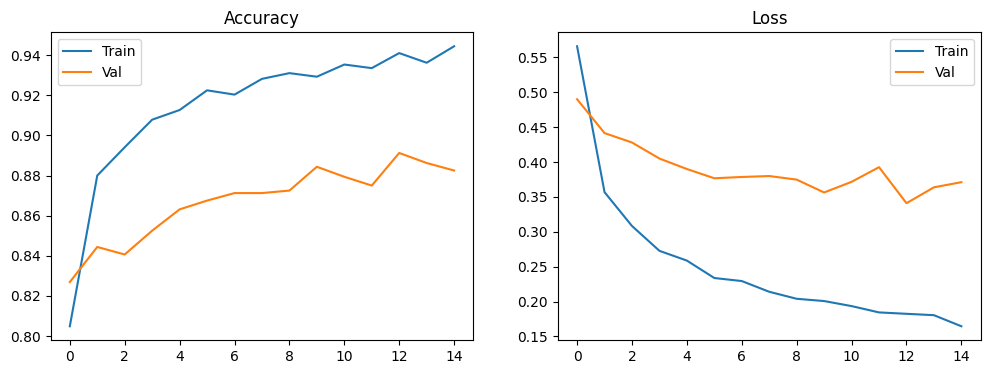

In [ ]:
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history.history["accuracy"], label="Train")
plt.plot(history.history["val_accuracy"], label="Val")
plt.title("Accuracy")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history["loss"], label="Train")
plt.plot(history.history["val_loss"], label="Val")
plt.title("Loss")
plt.legend()

plt.show()

In [ ]:
model.save("brain_tumor_model.keras")
model = tf.keras.models.load_model("brain_tumor_model.keras", compile=False)

Saving Screenshot 2026-02-12 200355.png to Screenshot 2026-02-12 200355.png
1/1 ━━━━━━━━━━━━━━━━━━━━ 15s 15s/step
Tumor Type: meningioma, Confidence: 0.30


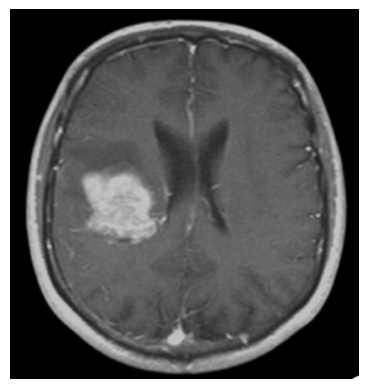

In [ ]:
from tensorflow.keras.preprocessing import image


from PIL import Image
import matplotlib.pyplot as plt


from google.colab import files
uploaded = files.upload()

filename = list(uploaded.keys())[0]   # get actual file name

img = Image.open(filename)
plt.imshow(img)
plt.axis("off")


def predict_image(img_path):
    img = image.load_img(img_path, target_size=(224,224))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array /= 255.0

    preds = model.predict(img_array)
    class_idx = np.argmax(preds)
    confidence = np.max(preds)

    return class_names[class_idx], confidence
label, conf = predict_image(filename)
print(f"Tumor Type: {label}, Confidence: {conf:.2f}")

In [ ]:
import tensorflow as tf

input_tensor = tf.keras.Input(shape=(224, 224, 3))
output_tensor = model(input_tensor)

gradcam_model = tf.keras.Model(inputs=input_tensor, outputs=output_tensor)
def get_efficientnet(model):
    for layer in model.layers:
        if isinstance(layer, tf.keras.Sequential):
            for sub_layer in layer.layers:
                if "efficientnet" in sub_layer.name.lower():
                    return sub_layer
    raise ValueError("EfficientNet not found in model")
base_model = tf.keras.applications.EfficientNetB0(
    include_top=False,
    weights="imagenet",
    input_shape=(224,224,3)
)

base_model.trainable = False  # important

x = base_model.output               # 🔴 KEEP feature maps
x = tf.keras.layers.GlobalAveragePooling2D()(x)
output = tf.keras.layers.Dense(len(class_names), activation="softmax")(x)

model = tf.keras.models.Model(inputs=base_model.input, outputs=output)

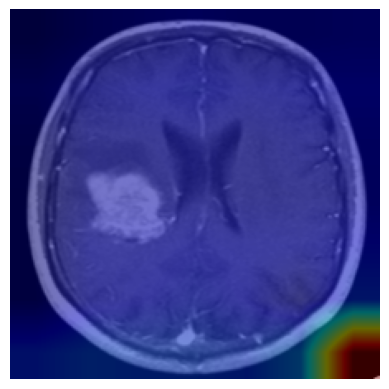

In [ ]:
import tensorflow as tf
import numpy as np
import cv2

def gradcam_on_image(img_path, model, img_size=(224,224)):

    img = tf.keras.utils.load_img(img_path, target_size=img_size)
    img_array = tf.keras.utils.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0) / 255.0

    # 🔹 Correct layer for EfficientNet
    last_conv = model.get_layer("top_conv")

    grad_model = tf.keras.models.Model(
        inputs=model.input,
        outputs=[last_conv.output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        class_idx = tf.argmax(predictions[0])
        loss = predictions[:, class_idx]

    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0,1,2))

    heatmap = tf.reduce_sum(conv_outputs[0] * pooled_grads, axis=-1)
    heatmap = tf.maximum(heatmap, 0)
    heatmap /= tf.reduce_max(heatmap) + 1e-8
    heatmap = heatmap.numpy()

    heatmap = cv2.resize(heatmap, img_size)
    heatmap = np.uint8(255 * heatmap)
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

    original = cv2.imread(img_path)
    original = cv2.resize(original, img_size)

    overlay = cv2.addWeighted(original, 0.6, heatmap, 0.4, 0)

    return overlay, class_idx.numpy(), predictions[0].numpy()

overlay, class_idx, preds = gradcam_on_image(filename, model)




import matplotlib.pyplot as plt
plt.imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

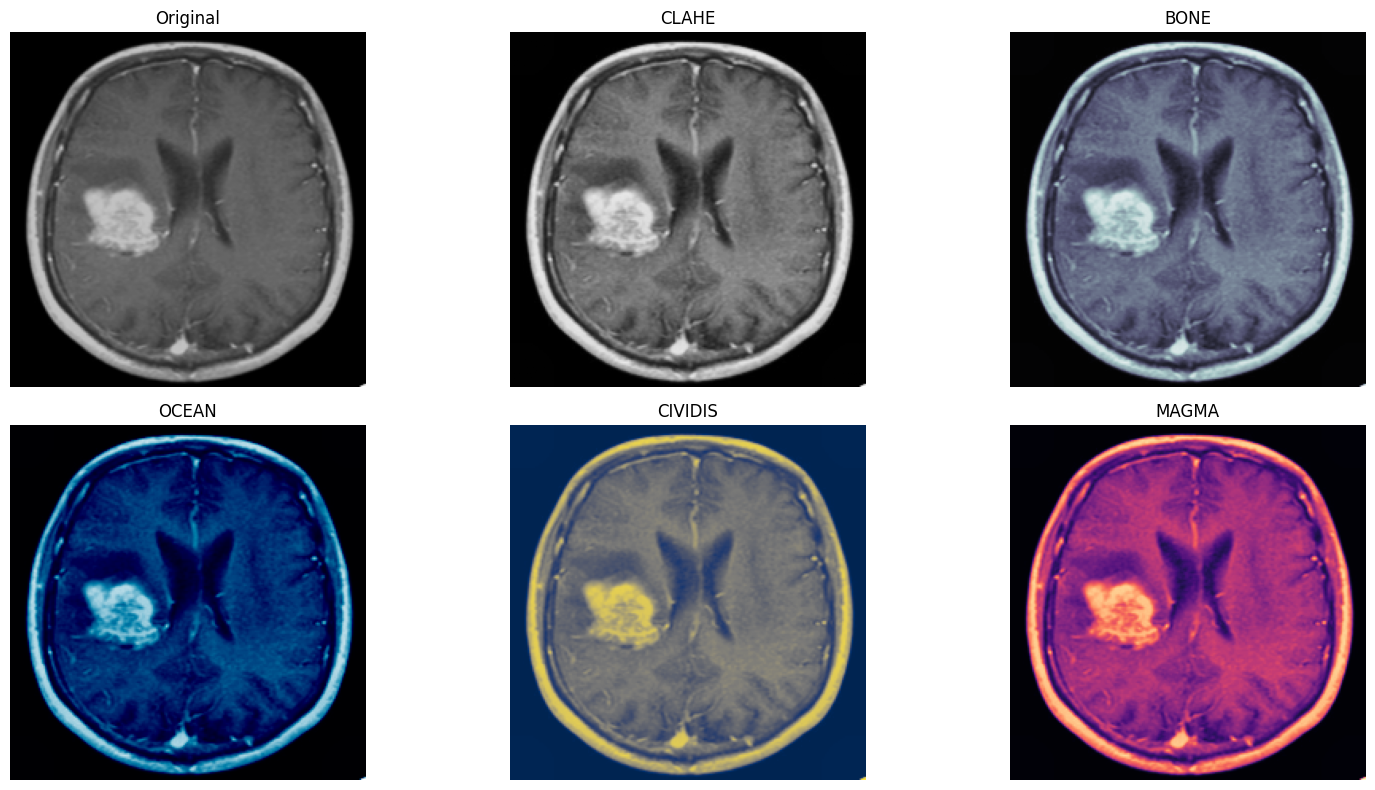

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread(filename, cv2.IMREAD_GRAYSCALE)
img = cv2.resize(img, (224,224))
original = img
hist_eq = cv2.equalizeHist(img)
# CLAHE (soft enhancement)
clahe = cv2.createCLAHE(clipLimit=1.5, tileGridSize=(8,8))
clahe_img = clahe.apply(img)

# Soft color maps (DEFINE THEM here)
bone = cv2.applyColorMap(clahe_img, cv2.COLORMAP_BONE)
ocean = cv2.applyColorMap(clahe_img, cv2.COLORMAP_OCEAN)
cividis = cv2.applyColorMap(clahe_img, cv2.COLORMAP_CIVIDIS)
magma = cv2.applyColorMap(clahe_img, cv2.COLORMAP_MAGMA)
images = [
    ("Original", img, "gray"),
    ("CLAHE", clahe_img, "gray"),
    ("BONE", bone, "color"),
    ("OCEAN", ocean, "color"),
    ("CIVIDIS", cividis, "color"),
    ("MAGMA", magma, "color"),
]

plt.figure(figsize=(16,8))

for i, (title, im, mode) in enumerate(images):
    plt.subplot(2,3,i+1)
    if mode == "gray":
        plt.imshow(im, cmap="gray")
    else:
        plt.imshow(cv2.cvtColor(im, cv2.COLOR_BGR2RGB))
    plt.title(title)
    plt.axis("off")

plt.tight_layout()
plt.show()

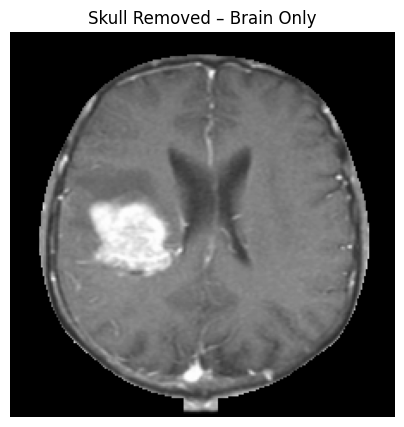

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Convert to grayscale
if len(img.shape) == 3:
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
else:
    gray = img.copy()

gray = gray.astype(np.float32) / 255.0

# Threshold to separate head from background
_, thresh = cv2.threshold((gray*255).astype(np.uint8), 10, 255, cv2.THRESH_BINARY)

# Morphology to fill brain region
kernel = np.ones((7,7), np.uint8)
thresh = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, kernel)

# Find contours
contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# Take largest contour = head
largest = max(contours, key=cv2.contourArea)

# Create brain mask
brain_mask = np.zeros_like(gray, dtype=np.uint8)
cv2.drawContours(brain_mask, [largest], -1, 1, -1)

# Erode to REMOVE skull ring
brain_mask = cv2.erode(brain_mask, np.ones((15,15), np.uint8))

# Apply mask
brain_only = gray * brain_mask

# Show result
plt.figure(figsize=(5,5))
plt.imshow(brain_only, cmap="gray")
plt.title("Skull Removed – Brain Only")
plt.axis("off")
plt.show()

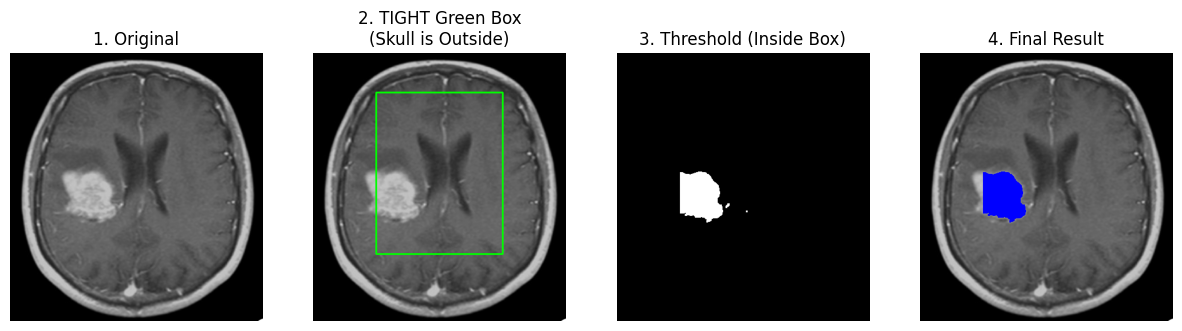

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread(filename)
if img is None:
    print(f"❌ Error: Could not read {filename}")
    exit()

gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# --- 2. DEFINE THE "TIGHT" GREEN BOX ---
height, width = gray.shape

# WE CUT MORE OFF THE SIDES NOW (25% instead of 15%)
# This guarantees the skull is outside the box.
x_start = int(width * 0.25)   # Start 25% from left
x_end = int(width * 0.75)     # End 25% from right (Total width is now 50%)

y_start = int(height * 0.15)  # Cut top 15%
y_end = int(height * 0.75)    # Cut bottom 25% (Neck)

# Create the mask
mask = np.zeros_like(gray)
cv2.rectangle(mask, (x_start, y_start), (x_end, y_end), 255, -1)

# --- 3. APPLY THE CUT ---
# Force everything outside the tight box to be black
brain_center = cv2.bitwise_and(gray, gray, mask=mask)

# --- 4. DETECT TUMOR ---
# Find brightest spot in the center
min_val, max_val, min_loc, max_loc = cv2.minMaxLoc(brain_center)

# Threshold logic
if max_val > 0:
    thresh_val = max_val * 0.70
    _, binary = cv2.threshold(brain_center, thresh_val, 255, cv2.THRESH_BINARY)
else:
    binary = np.zeros_like(gray)

# Clean up
binary = cv2.morphologyEx(binary, cv2.MORPH_OPEN, np.ones((3,3), np.uint8))

# --- 5. SELECT TUMOR ---
final_mask = np.zeros_like(gray)
contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

if contours:
    # Pick the largest blob in the box
    largest_blob = max(contours, key=cv2.contourArea)
    if cv2.contourArea(largest_blob) > 200:
        cv2.drawContours(final_mask, [largest_blob], -1, 255, -1)

# --- 6. DISPLAY ---
overlay = img.copy()
overlay[final_mask == 255] = [255, 0, 0] # Red Tumor

# Draw the new TIGHT box
debug_img = img.copy()
cv2.rectangle(debug_img, (x_start, y_start), (x_end, y_end), (0, 255, 0), 2)

plt.figure(figsize=(15, 5))

plt.subplot(1, 4, 1)
plt.title("1. Original")
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis('off')

plt.subplot(1, 4, 2)
plt.title("2. TIGHT Green Box\n(Skull is Outside)")
plt.imshow(cv2.cvtColor(debug_img, cv2.COLOR_BGR2RGB))
plt.axis('off')

plt.subplot(1, 4, 3)
plt.title("3. Threshold (Inside Box)")
plt.imshow(binary, cmap='gray')
plt.axis('off')

plt.subplot(1, 4, 4)
plt.title("4. Final Result")
plt.imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
plt.axis('off')

plt.show()

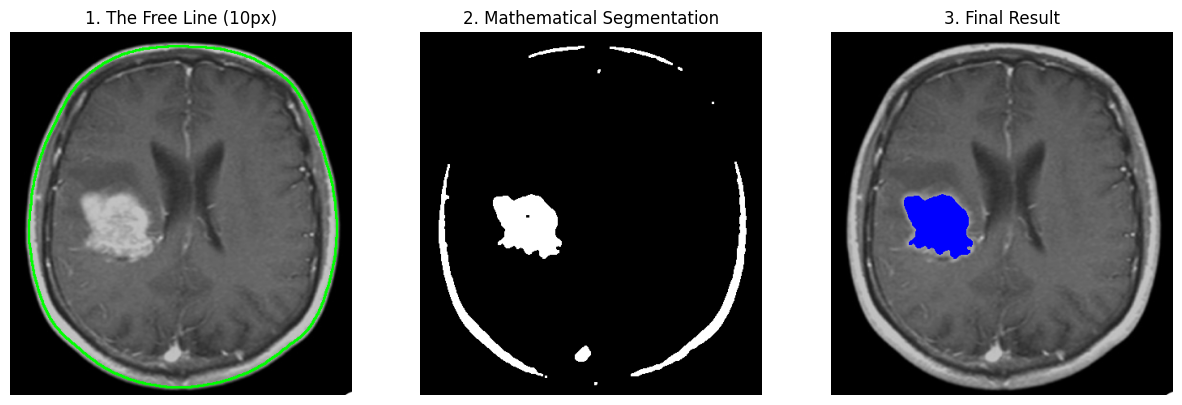

✅ Process Complete.


In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

if not os.path.exists(filename):
    print(f"❌ Error: {filename} not found.")
else:
    img = cv2.imread(filename)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Initialize variables to prevent NameError
    tumor_mask = np.zeros_like(gray)
    final_mask = np.zeros_like(gray)
    tumor_found = False

    # --- 2. PREPROCESSING (Paper: Median Filter) ---
    # Removes noise (grain) so the math works better
    gray_filtered = cv2.medianBlur(gray, 5)

    # --- 3. CREATE "FREE GREEN LINE" (Skull Hugging Mask) ---
    _, thresh_head = cv2.threshold(gray_filtered, 10, 255, cv2.THRESH_BINARY)
    contours, _ = cv2.findContours(thresh_head, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    skull_mask = np.zeros_like(gray)
    if contours:
        largest_cnt = max(contours, key=cv2.contourArea)
        cv2.drawContours(skull_mask, [largest_cnt], -1, 255, -1)

        # Erode by 10 pixels (Your preferred "Green Line" setting)
        # Removes skull bone but keeps tumor
        skull_mask = cv2.erode(skull_mask, np.ones((10,10), np.uint8), iterations=1)
    else:
        print("⚠️ Warning: No brain shape detected. Using full image.")
        skull_mask = np.ones_like(gray) * 255

    # --- 4. FUZZY C-MEANS (FCM) LOGIC ---
    # We look strictly inside the Green Line
    brain_only = cv2.bitwise_and(gray_filtered, gray_filtered, mask=skull_mask)

    # Get pixels for clustering
    pixel_values = brain_only[skull_mask == 255].reshape((-1, 1))
    pixel_values = np.float32(pixel_values)

    # CHECK: Do we have enough data?
    if len(pixel_values) > 0:
        # Define Criteria (Epsilon & Max Iterations)
        criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 100, 0.2)

        # Ask for 4 clusters: Background, Grey Matter, White Matter, TUMOR
        k = 4
        _, labels, centers = cv2.kmeans(pixel_values, k, None, criteria, 10, cv2.KMEANS_PP_CENTERS)

        # The Tumor is the "Brightest" Cluster
        centers = np.uint8(centers)
        sorted_indices = np.argsort(centers.flatten())
        tumor_cluster_index = sorted_indices[-1] # The brightest group

        # Map back to image
        segmentation_map = np.zeros_like(gray)
        # Use a safe way to index
        brain_indices = np.where(skull_mask == 255)
        if len(brain_indices[0]) == len(labels):
            segmentation_map[brain_indices] = labels.flatten()

            # Extract just the Tumor Cluster
            tumor_mask[segmentation_map == tumor_cluster_index] = 255
            tumor_found = True
        else:
             print("⚠️ Shape mismatch in clustering. Using fallback.")
    else:
        print("⚠️ Image is empty inside the mask.")

    # --- 5. FALLBACK (If FCM fails, use Thresholding) ---
    if not tumor_found or cv2.countNonZero(tumor_mask) == 0:
        print("ℹ️ FCM Math failed to find a distinct blob. Switching to 'Brightest Spot' logic.")
        min_val, max_val, min_loc, max_loc = cv2.minMaxLoc(brain_only)
        if max_val > 0:
            thresh_val = max_val * 0.70 # Top 30% brightness
            _, tumor_mask = cv2.threshold(brain_only, thresh_val, 255, cv2.THRESH_BINARY)

    # --- 6. CLEAN UP & VISUALIZE ---
    # Morphological Open (Removes small white noise specs)
    tumor_mask = cv2.morphologyEx(tumor_mask, cv2.MORPH_OPEN, np.ones((3,3), np.uint8))

    contours, _ = cv2.findContours(tumor_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if contours:
        # Pick largest blob
        largest = max(contours, key=cv2.contourArea)
        if cv2.contourArea(largest) > 50:
            cv2.drawContours(final_mask, [largest], -1, 255, -1)

    overlay = img.copy()
    overlay[final_mask == 255] = [255, 0, 0] # Red Tumor

    # Draw Green Line
    debug_img = img.copy()
    line_contours, _ = cv2.findContours(skull_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    cv2.drawContours(debug_img, line_contours, -1, (0, 255, 0), 2)

    plt.figure(figsize=(15, 6))

    plt.subplot(1, 3, 1)
    plt.title("1. The Free Line (10px)")
    plt.imshow(cv2.cvtColor(debug_img, cv2.COLOR_BGR2RGB))
    plt.axis('off')

    plt.subplot(1, 3, 2)
    plt.title("2. Mathematical Segmentation")
    plt.imshow(tumor_mask, cmap='gray')
    plt.axis('off')

    plt.subplot(1, 3, 3)
    plt.title("3. Final Result")
    plt.imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
    plt.axis('off')

    plt.show()
    print("✅ Process Complete.")

📸 Processing Screenshot 2026-02-12 200355.png...


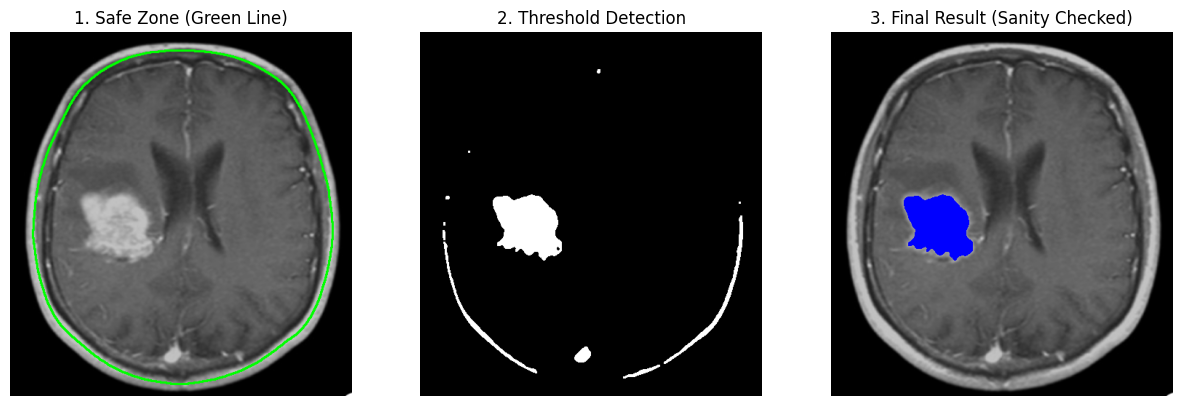

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os



if not os.path.exists(filename):
    print(f"❌ Error: {filename} not found.")
else:
    print(f"📸 Processing {filename}...")

    # 1. LOAD & STANDARDIZE
    img_original = cv2.imread(filename)
    if img_original is None:
        print("❌ Error: Image format not recognized.")
    else:
        # Resize to 500px height for consistency
        height, width = img_original.shape[:2]
        scale_factor = 500 / height
        new_width = int(width * scale_factor)
        img = cv2.resize(img_original, (new_width, 500))
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

        # 2. SKULL STRIPPING (The "Hole Punch")
        # Blur to remove noise
        gray_blur = cv2.medianBlur(gray, 5)

        # Find the Head Outline
        _, thresh_head = cv2.threshold(gray_blur, 45, 255, cv2.THRESH_BINARY)

        # Clean up thin connections
        kernel_clean = np.ones((5,5), np.uint8)
        thresh_head = cv2.morphologyEx(thresh_head, cv2.MORPH_OPEN, kernel_clean)

        # Find Largest Contour (The Head)
        contours, _ = cv2.findContours(thresh_head, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

        brain_mask = np.zeros_like(gray)
        if contours:
            largest_cnt = max(contours, key=cv2.contourArea)
            cv2.drawContours(brain_mask, [largest_cnt], -1, 255, -1)

            # AGGRESSIVE EROSION (20 Pixels)
            # This creates the "Safe Zone" deep inside the brain
            kernel_erode = np.ones((20, 20), np.uint8)
            safe_zone_mask = cv2.erode(brain_mask, kernel_erode, iterations=1)
        else:
            # Fallback if image is weird
            safe_zone_mask = np.zeros_like(gray)
            h, w = gray.shape
            cv2.rectangle(safe_zone_mask, (50, 50), (w-50, h-50), 255, -1)

        # 3. TUMOR DETECTION (Brightest Blob in Safe Zone)
        # Look ONLY inside the safe zone
        brain_focus = cv2.bitwise_and(gray_blur, gray_blur, mask=safe_zone_mask)

        # Find max brightness inside
        min_val, max_val, min_loc, max_loc = cv2.minMaxLoc(brain_focus)

        # Threshold: Keep top 20% brightness inside the safe zone
        if max_val > 0:
            thresh_val = max_val * 0.80
            _, binary = cv2.threshold(brain_focus, thresh_val, 255, cv2.THRESH_BINARY)
        else:
            binary = np.zeros_like(gray)

        # Clean up noise
        binary = cv2.morphologyEx(binary, cv2.MORPH_OPEN, np.ones((3,3), np.uint8))

        # 4. FILTERING (The "Sanity Check")
        # Prevents selecting the whole screen
        final_mask = np.zeros_like(gray)
        contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

        tumor_found = False
        if contours:
            # Sort by Area (Largest to Smallest)
            sorted_cnts = sorted(contours, key=cv2.contourArea, reverse=True)

            for cnt in sorted_cnts:
                area = cv2.contourArea(cnt)
                image_area = gray.shape[0] * gray.shape[1]

                # RULE 1: Must be bigger than noise (>50px)
                # RULE 2: Must be smaller than 20% of the image (Tumors aren't 100% of the head)
                if 50 < area < (image_area * 0.20):
                    cv2.drawContours(final_mask, [cnt], -1, 255, -1)
                    tumor_found = True
                    break # Found the best candidate, stop.

        if not tumor_found:
             print("⚠️ No valid tumor found (All candidates failed size check).")

        # 5. VISUALIZE
        overlay = img.copy()
        overlay[final_mask == 255] = [255, 0, 0] # Red Tumor

        # Draw Green Line
        debug_img = img.copy()
        line_cnts, _ = cv2.findContours(safe_zone_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        cv2.drawContours(debug_img, line_cnts, -1, (0, 255, 0), 2)

        plt.figure(figsize=(15, 6))

        plt.subplot(1, 3, 1)
        plt.title("1. Safe Zone (Green Line)")
        plt.imshow(cv2.cvtColor(debug_img, cv2.COLOR_BGR2RGB))
        plt.axis('off')

        plt.subplot(1, 3, 2)
        plt.title("2. Threshold Detection")
        plt.imshow(binary, cmap='gray')
        plt.axis('off')

        plt.subplot(1, 3, 3)
        plt.title("3. Final Result (Sanity Checked)")
        plt.imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
        plt.axis('off')

        plt.show()